# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook take our best variant of the models and *test them on a holdout dataset*, the test dataset we created in ELT.
* **Previos step**: `Cross_Validation.ipynb`
* **Enviroment**: Jupyter in an Ubuntu VM
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
  * **Files used in this Notebook**: `utils.py`
* **Output**:
  * Generate a `model_results.csv` file with the statistic data
    * Columns added: test_acc,test_kappa,cf_matrix_path
* **Files used in this Notebook**: `utils.py`

# Imports

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
import joblib
import ast
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.optimize import minimize

I0000 00:00:1782484324.158463 3434969 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782484325.526681 3434969 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
import utils

In [4]:
test_path_csv = 'process_dataset/extracted_features/test_features.csv'
test_path_raw = 'process_dataset/test'
class_distribution_path = 'process_dataset/class_distribution_train.csv'

In [43]:
results = pd.read_csv("./model_results.csv")

results['test_acc'] = None
results['test_kappa'] = None
results['cf_matrix_path']=None

probas = []

# Dataset

In [ ]:
df_test = pd.read_csv(test_path_csv)
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']
feature_cols = [c for c in df_test.columns if c not in cols_to_drop]
X_test = df_test[feature_cols]
y_test = df_test['Label']

# Generate the test

In [ ]:
def run_test_model(model_name, model, X_or_gen, y_true, results, mask, save_folder):

    # sklearn mocdlx
    if model_name in ["LGBM", "XGB", "RF", "LDA", "LR"]:
        y_proba = model.predict_proba(X_or_gen)
        y_pred = model.predict(X_or_gen)

    # Keras models on tabular data
    elif model_name in ["MLP", "LSTM", "ResNet"]:
        X_arr = np.array(X_or_gen)
    
        if "lstm" in model_name.lower() or "resnet" in model_name.lower():
            if X_arr.ndim == 2:
                X_arr = X_arr.reshape(X_arr.shape[0], 1, X_arr.shape[1])
    
        y_proba = model.predict(X_arr)
    
        if y_proba.ndim == 1:
            # One-hot conversion for binary classification
            num_classes = len(np.unique(y_true))
            y_proba_fixed = np.zeros((len(y_proba), num_classes))
            y_proba_fixed[np.arange(len(y_proba)), y_proba.astype(int)] = 1
            y_proba = y_proba_fixed
    
        y_pred = y_proba.argmax(axis=1)

    # models with raw data/ generators
    elif model_name in ["CNN", "SSN"]:
        all_y = []
        for i in range(len(X_or_gen)):
            _, yb = X_or_gen[i]
            all_y.append(np.argmax(yb, axis=1))
        y_true = np.concatenate(all_y)

        y_proba = model.predict(X_or_gen)
        y_pred = y_proba.argmax(axis=1)

    else:
        raise ValueError(f"Unknown model type: {model_name}")

    # metrics
    acc, kappa, cf_path = utils.evaluate_model(
        y_true,
        y_pred,
        save_folder=save_folder,
        model_name=model_name
    )

    results.loc[mask, 'test_acc'] = acc
    results.loc[mask, 'test_kappa'] = kappa
    results.loc[mask, 'cf_matrix_path'] = cf_path

    return y_proba

# Models test

## LightGBM

Confusion matrix saved at: ./results/confusion_matrix_LGBM.png
Accuracy: 0.7811
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



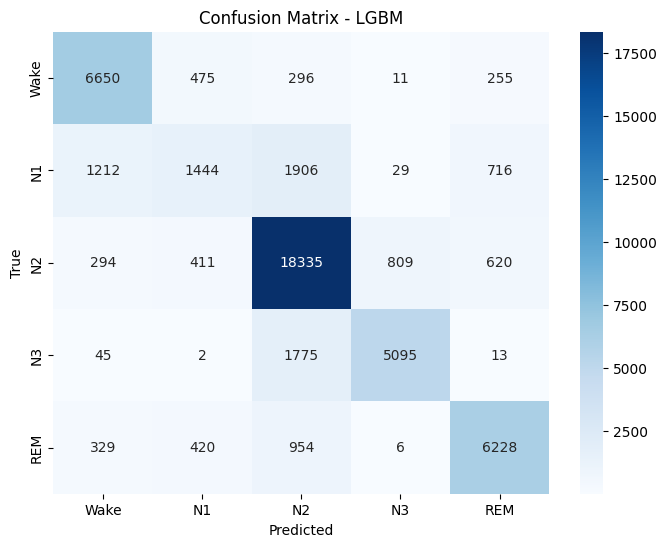

Cohen's Kappa: 0.6950


In [44]:
model_name = 'LGBM'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## XGBoost

Confusion matrix saved at: ./results/confusion_matrix_XGB.png
Accuracy: 0.7804
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.86      0.82      7687
          N1       0.52      0.28      0.36      5307
          N2       0.79      0.89      0.84     20469
          N3       0.85      0.73      0.79      6930
         REM       0.79      0.79      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



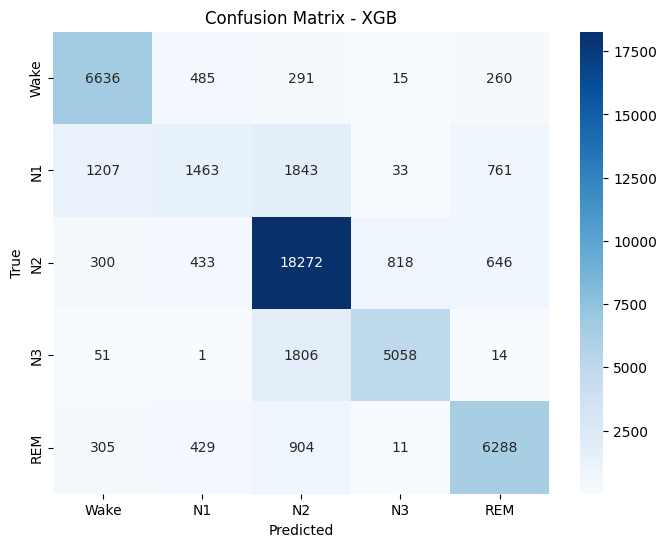

Cohen's Kappa: 0.6943


In [45]:
model_name = 'XGB'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## Random Forest

Confusion matrix saved at: ./results/confusion_matrix_RF.png
Accuracy: 0.7523
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.72      0.82      0.77      7687
          N1       0.49      0.24      0.32      5307
          N2       0.78      0.87      0.82     20469
          N3       0.85      0.70      0.77      6930
         REM       0.74      0.79      0.76      7937

    accuracy                           0.75     48330
   macro avg       0.71      0.68      0.69     48330
weighted avg       0.74      0.75      0.74     48330



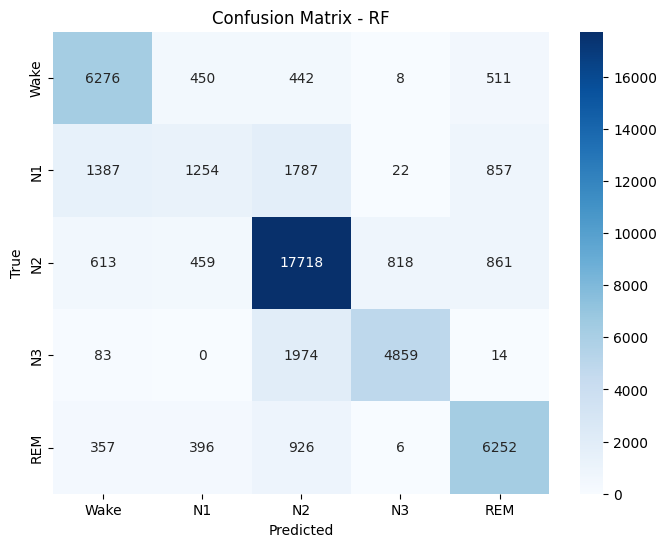

Cohen's Kappa: 0.6557


In [46]:
model_name = 'RF'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## LDA

Confusion matrix saved at: ./results/confusion_matrix_LDA.png
Accuracy: 0.7352
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.76      0.72      0.74      7687
          N1       0.41      0.31      0.35      5307
          N2       0.77      0.85      0.81     20469
          N3       0.79      0.69      0.74      6930
         REM       0.72      0.79      0.75      7937

    accuracy                           0.74     48330
   macro avg       0.69      0.67      0.68     48330
weighted avg       0.73      0.74      0.73     48330



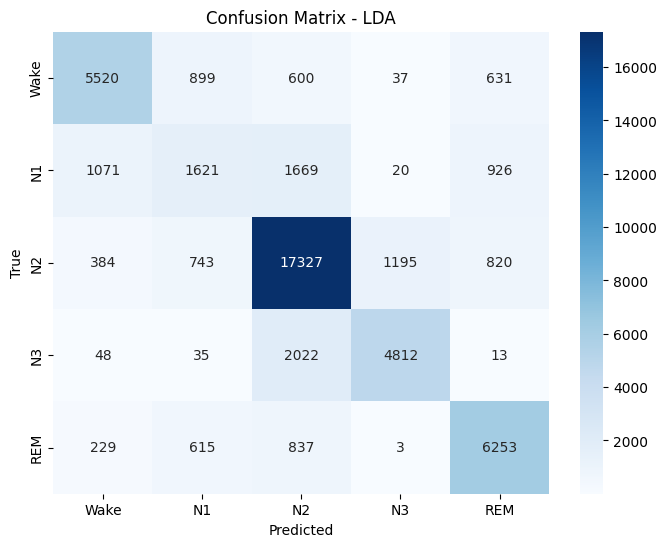

Cohen's Kappa: 0.6338


In [47]:
model_name = 'LDA'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## Logistic Regression

Confusion matrix saved at: ./results/confusion_matrix_LR.png
Accuracy: 0.7213
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.73      0.74      7687
          N1       0.35      0.44      0.39      5307
          N2       0.87      0.72      0.79     20469
          N3       0.72      0.84      0.77      6930
         REM       0.69      0.81      0.75      7937

    accuracy                           0.72     48330
   macro avg       0.68      0.71      0.69     48330
weighted avg       0.74      0.72      0.73     48330



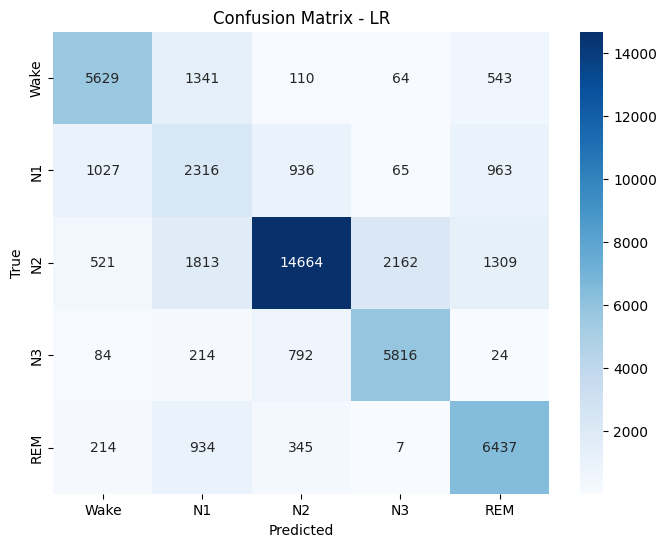

Cohen's Kappa: 0.6319


In [48]:
model_name = 'LR'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## MLP

Confusion matrix saved at: ./results/confusion_matrix_MLP.png
Accuracy: 0.7213
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.73      0.74      7687
          N1       0.35      0.44      0.39      5307
          N2       0.87      0.72      0.79     20469
          N3       0.72      0.84      0.77      6930
         REM       0.69      0.81      0.75      7937

    accuracy                           0.72     48330
   macro avg       0.68      0.71      0.69     48330
weighted avg       0.74      0.72      0.73     48330



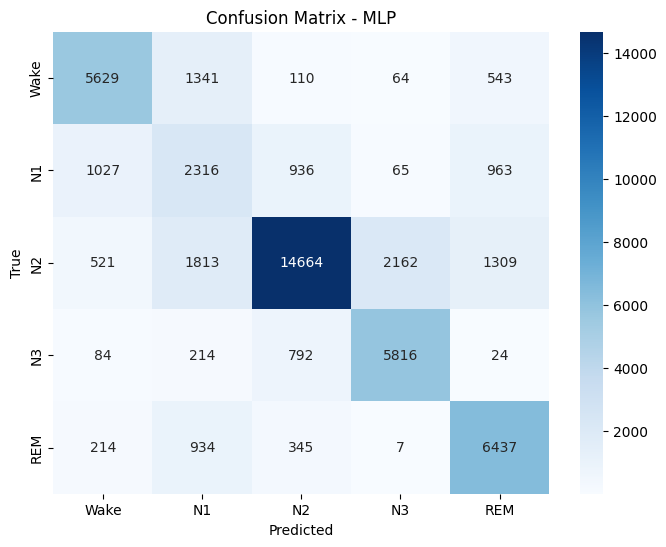

Cohen's Kappa: 0.6319


In [49]:
model_name = 'MLP'
mask = (results['name'] == model_name)
mlp_model = load_model(results.loc[mask,'path'].values[0])

probas.append( run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## LSTM

1511/1511 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
Confusion matrix saved at: ./results/confusion_matrix_LSTM.png
Accuracy: 0.7681
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.87      0.81      7687
          N1       0.51      0.26      0.34      5307
          N2       0.81      0.84      0.82     20469
          N3       0.79      0.77      0.78      6930
         REM       0.75      0.82      0.78      7937

    accuracy                           0.77     48330
   macro avg       0.72      0.71      0.71     48330
weighted avg       0.75      0.77      0.76     48330



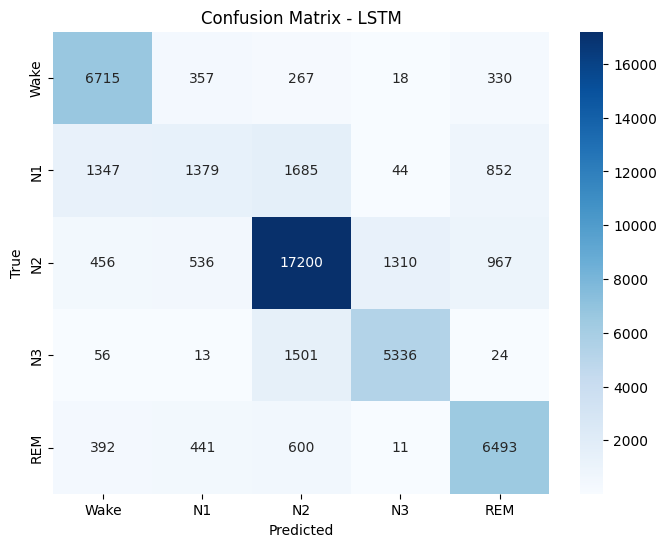

Cohen's Kappa: 0.6818


In [50]:
mask = (results['name'] == 'LSTM')
model_name = 'LSTM'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0],
    custom_objects={
        "se_feature_attention": utils.se_feature_attention,
        "focal_loss": utils.categorical_focal_loss
    },
    compile=False
)

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## ResNet

1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion matrix saved at: ./results/confusion_matrix_ResNet.png
Accuracy: 0.7772
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.85      0.82      7687
          N1       0.52      0.29      0.37      5307
          N2       0.78      0.89      0.83     20469
          N3       0.88      0.67      0.76      6930
         REM       0.78      0.82      0.80      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.76     48330



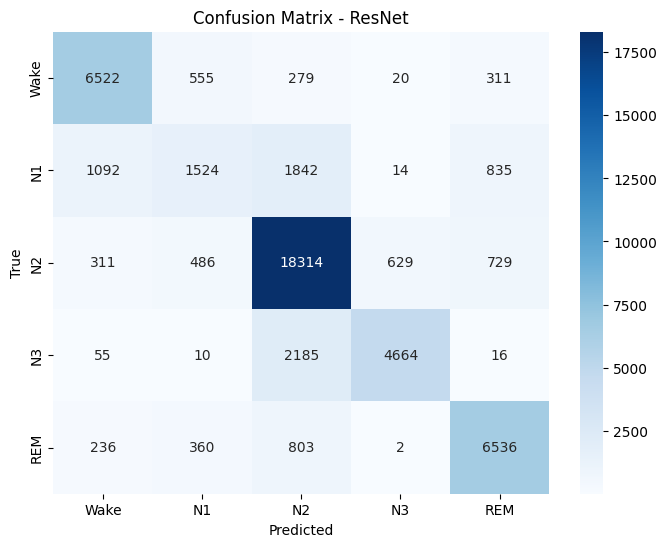

Cohen's Kappa: 0.6890


In [51]:
model_name = 'ResNet'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0],
    compile=False
)

probas.append(run_test_model(
        model_name = model_name,
        model = model,
        X_or_gen = X_test,
        y_true = y_test,
        results= results,
        mask = mask,
        save_folder = "./results"
    )
)

## 1D-CNN

57/57 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step
Confusion matrix saved at: ./results/confusion_matrix_CNN.png
Accuracy: 0.7704
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.94      0.82      7621
          N1       0.51      0.19      0.27      5260
          N2       0.80      0.87      0.83     20468
          N3       0.79      0.77      0.78      6930
         REM       0.77      0.75      0.76      7937

    accuracy                           0.77     48216
   macro avg       0.72      0.70      0.69     48216
weighted avg       0.75      0.77      0.75     48216



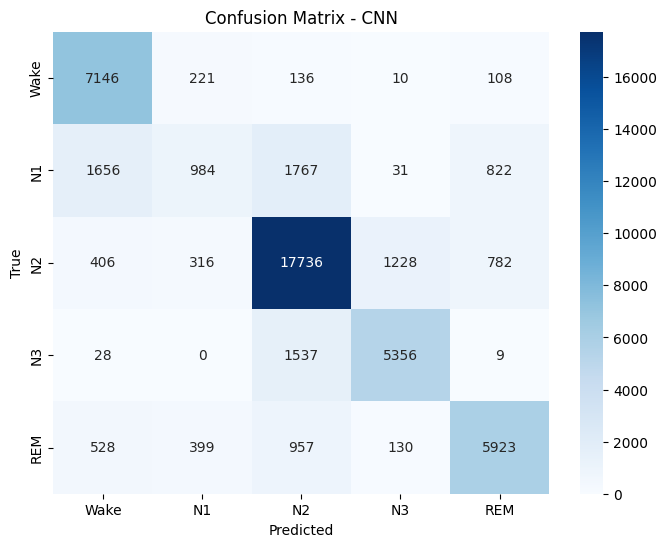

Cohen's Kappa: 0.6822


In [19]:
test_gen = utils.SleepDataGenerator(
    test_path_raw,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

model_name = 'CNN'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0], 
    compile=False
)

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = test_gen,
    y_true = None,
    results= results,
    mask = mask,
    save_folder = "./results"
)

## SeqSleepNet

57/57 ━━━━━━━━━━━━━━━━━━━━ 1080s 18s/step
Confusion matrix saved at: ./results/confusion_matrix_SSN.png
Accuracy: 0.7655
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.87      0.83      7621
          N1       0.49      0.28      0.35      5260
          N2       0.80      0.85      0.82     20468
          N3       0.79      0.78      0.78      6930
         REM       0.73      0.77      0.75      7937

    accuracy                           0.77     48216
   macro avg       0.72      0.71      0.71     48216
weighted avg       0.75      0.77      0.75     48216



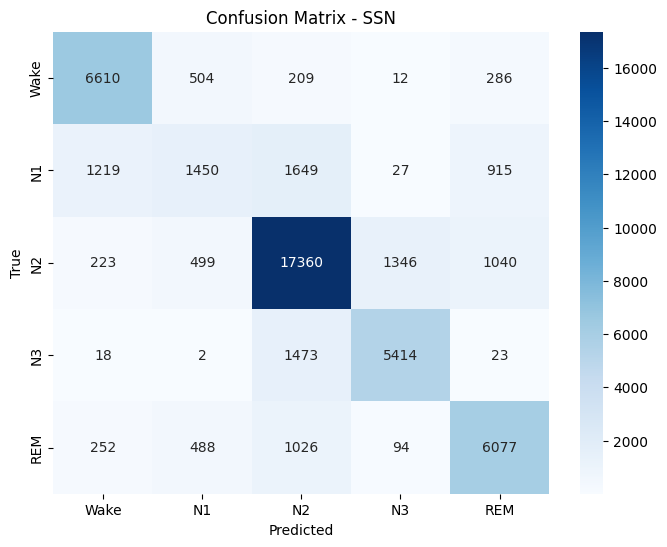

Cohen's Kappa: 0.6770


In [21]:
import utils
test_gen_seq = utils.SleepDataGenerator(
    test_path_raw,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0] 
)

model_name = 'SSN'
mask = (results['name'] == model_name)

custom_objects = {
    "Attention": utils.Attention,
    "se_feature_attention": utils.se_feature_attention,
    "categorical_focal_loss": utils.categorical_focal_loss(),
    "loss": utils.categorical_focal_loss(),
}

model = load_model(
    results.loc[mask, 'path'].values[0],
    custom_objects=custom_objects,
    compile=False
)

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = test_gen_seq,
    y_true = None,
    results= results,
    mask = mask,
    save_folder = "./results"
)

# Ensemble

## Search for weights

In [ ]:
def loss_fn(weights):
    weights = np.abs(weights)
    weights = weights / np.sum(weights)

    final_proba = np.zeros_like(probas[0])
    for w, p in zip(weights, probas):
        final_proba += w * p

    final_pred = np.argmax(final_proba, axis=1)
    acc = accuracy_score(y_test, final_pred)
    return -acc

In [52]:
probas = [p.astype(float) for p in probas]
n_models = len(probas)
n_classes = probas[0].shape[1]
w0 = np.ones(n_models) / n_models

res = minimize(
    loss_fn,
    w0,
    method='Nelder-Mead',
    options={'maxiter': 800, 'disp': True}
)

best_w = np.abs(res.x)
best_w = best_w / np.sum(best_w)
print(best_w)

Optimization terminated successfully.
         Current function value: -0.788206
         Iterations: 133
         Function evaluations: 258
[0.26681476 0.15148718 0.11777835 0.05446613 0.09354222 0.02336733
 0.02836159 0.26418243]


In [66]:
model_names = [
    "LGBM",
    "XGB",
    "RF",
    "LDA",
    "LR",
    "MLP",
    "LSTM",
    "ResNet"
]

df_ensemble = pd.DataFrame({
    "model_name": model_names,
    "probas" : [p.tolist() for p in probas],
    "weight": None
})

for idx, w in enumerate(best_w):
    if w != 0:
        df_ensemble.loc[
            df_ensemble['model_name'] == model_names[idx],
            'weight'
        ] = w

df_ensemble.to_csv("ensemble_weights.csv", index=False)

## Final Tabular Ensemble

Confusion matrix saved at: ./results/confusion_matrix_ENS_Tab.png
Accuracy: 0.7882
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.88      0.83      7687
          N1       0.54      0.29      0.38      5307
          N2       0.80      0.89      0.84     20469
          N3       0.87      0.73      0.79      6930
         REM       0.78      0.82      0.80      7937

    accuracy                           0.79     48330
   macro avg       0.76      0.72      0.73     48330
weighted avg       0.78      0.79      0.78     48330



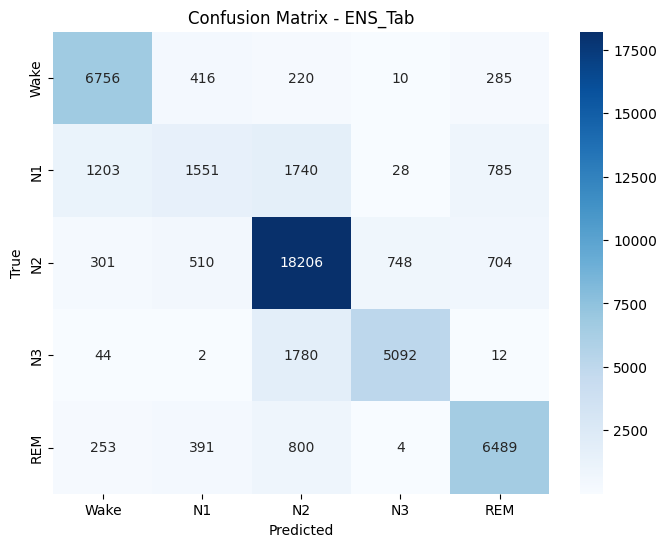

Cohen's Kappa: 0.7060

=== The contribution of each model in the ensemble ===
LGBM   | weight=26.68%
XGB    | weight=15.15%
RF     | weight=11.78%
LDA    | weight=5.45%
LR     | weight=9.35%
MLP    | weight=2.34%
LSTM   | weight=2.84%
ResNet | weight=26.42%


In [81]:
df_ensemble = pd.read_csv("ensemble_weights.csv")

df_ensemble["probas"] = df_ensemble["probas"].apply(lambda x: np.array(ast.literal_eval(x)))
for _, row in df_ensemble.iterrows():
    ens_proba += row['probas'] * row['weight']

ens_pred = np.argmax(ens_proba, axis=1)

acc, kappa,save_path = utils.evaluate_model(
    y_test,
    ens_pred,
    save_folder="./results",
    model_name='ENS_Tab'
)

print("\n=== The contribution of each model in the ensemble ===")
for _, row in df_ensemble.iterrows():
    contrib = np.mean(w * p)
    print(f"{row['model_name']:6s} | weight={(row['weight']*100):.2f}%")

In [ ]:
results.loc[len(results)] = {
    'full_name': 'Tabular Ensemble',
    'name': 'ENS_Tab',
    'type':'Ensemble',
    'acc_mean':None,
    'acc_std':None,
    'kappa_mean':None,
    'kappa_std':None,
    'acc_best':None,
    'kappa_best':None,
    'fold_accs':None,
    'fold_kappas':None,
    'path':None,
    'test_acc':acc,
    'test_kappa':kappa,
    'cf_matrix_path':save_path,
    'details':'ensemble_weights.csv'
}

# Results

In [85]:
results.to_csv("./model_results.csv", index=False)